# Exam - Clarissa Eisenbach & Moritz Toppmöller

Workflow:
1. Installation of necessary libraries
2. Exploration of the dataset
3. Research Question
4. Data Preprocessing
5. Model Development
6. Evaluation and Validation

## 1. Installation

In [1]:
# Using Python 3.14
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## 2. Exploration of the dataset

### The Myocardial infarction complications Database 
The database can be found at https://figshare.le.ac.uk/articles/dataset/Myocardial_infarction_complications_Database/12045261 with labeled columns
in the Machine Learning Repository the dataset does not have labeled colums https://archive.ics.uci.edu/dataset/579/myocardial+infarction+complications 


The dataset includes data on patients collected in the hospital after Myocardial Infarction (MI) on admission day and day three, and complications. 
Predicting complications after MI allows the clinician to provide preventive measures to the patient in time. 

### Dataset: 

1700 Patients (Rows)

#### column 1: index

#### colums 2-112: input data 
    2-3: demographic data
    4-34 preexisting conditions / symptoms /findings
    35-75 : findings on admission (BP, clinical, mostly ECG findings)
    76-82 : fibrinolytic therapy
    83-91 : findings (Labs)
    92: time to treatment
    93-95: relapse of pain
    96-112 : therapy / drugs by Emergency medical team / in ICU on day 1, 2, 3

#### columns 113-124: outputs = possible complications and patient outcomes
    112-117: arrythmias
    118: pulmonary edema
    119: myogardial rupture
    120: dressler syndrome
    121: Chronic heart failure
    122: Relapse of MI
    123: Post-infarction angina
    124: lethal outcome (cause)

##### There are four possible time moments for complication prediction: on base of the information known at
1. the time of admission to hospital: all input columns (2-112) except 93, 94, 95, 100, 101,
102, 103, 104, 105 can be used for prediction;
2. the end of the first day (24 hours after admission to the hospital): all input columns (2- 112) except 94, 95, 101, 102, 104, 105 can be used for prediction;
3. the end of the second day (48 hours after admission to the hospital) all input columns (2- 112) except 95, 102, 105 can be used for prediction;
4. the end of the third day (72 hours after admission to the hospital) all input columns (2- 112) can be used for prediction




In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# import MIcomplications.csv into a pandas dataframe
mi_complications = pd.read_csv("MIcomplications.csv", index_col=0)
mi_complications.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
ID,,,,,,,,,,,,,,,,,,,,,
1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0
2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,...,0,0,0,0,0,0,1,0,0,0
5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0


### Outcome variable

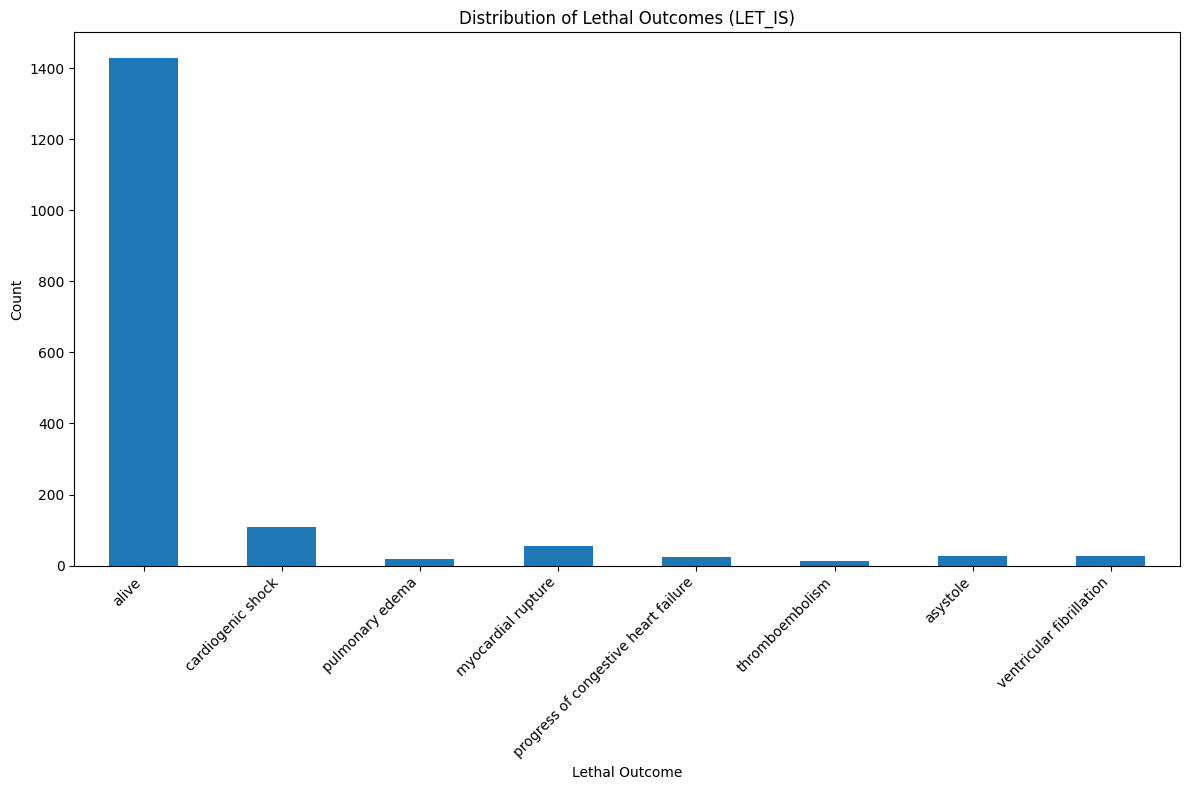

In [3]:
# show the distribution of the variable "LET_IS" in a bar plot
# note that 0 is called "alive" not "unknown" in the descriptive statistics document
labels = {
    0: "alive", 
    1: "cardiogenic shock",
    2: "pulmonary edema",
    3: "myocardial rupture",
    4: "progress of congestive heart failure",
    5: "thromboembolism",
    6: "asystole",
    7: "ventricular fibrillation"
}
plt.figure(figsize=(12, 8))
mi_complications["LET_IS"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Lethal Outcomes (LET_IS)")
plt.xlabel("Lethal Outcome")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(labels)),
    labels=[labels[i] for i in range(len(labels))],
    rotation=45,
    ha="right",
)
plt.tight_layout()
plt.show()

### Missing Values

In [4]:
# find out how many missing values are in the dataset
missing_values = mi_complications.isnull().sum()
print("Number of missing values: ", missing_values.sum(),
    "out of", mi_complications.size,
    "(", round(missing_values.sum() / mi_complications.size * 100, 2), "%)"
)
print("Number of corrupted rows: ", mi_complications[mi_complications.isnull().any(axis=1)].shape[0],
    "out of", mi_complications.shape[0],
    "(", round(mi_complications[mi_complications.isnull().any(axis=1)].shape[0] / mi_complications.shape[0] * 100, 2), "%)"
)

# show columns without missing values
columns_without_missing_values = missing_values[missing_values == 0].index.tolist()
print("Columns without missing values: ", columns_without_missing_values)

# show columns sorted by the number of missing values and their percentage of missing values
missing_values_sorted = missing_values[missing_values != 0].sort_values(ascending=False)
missing_values_percentage = (missing_values_sorted / mi_complications.size * 100).round(2)
missing_values_df = pd.DataFrame({"Missing Values": missing_values_sorted, "Percentage": missing_values_percentage})
print(missing_values_df)

# show rows with missing values sorted by the number of missing values
rows_with_missing_values = mi_complications[mi_complications.isnull().any(axis=1)]
rows_with_missing_values["Missing Count"] = rows_with_missing_values.isnull().sum(axis=1)
rows_with_missing_values_sorted = rows_with_missing_values.sort_values(by="Missing Count", ascending=False)
print(rows_with_missing_values_sorted[["Missing Count"]])

Number of missing values:  15974 out of 209100 ( 7.64 %)
Number of corrupted rows:  1700 out of 1700 ( 100.0 %)
Columns without missing values:  ['SEX', 'FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']
            Missing Values  Percentage
KFK_BLOOD             1696        0.81
IBS_NASL              1628        0.78
D_AD_KBRIG            1076        0.51
S_AD_KBRIG            1076        0.51
NOT_NA_KB              686        0.33
...                    ...         ...
zab_leg_06               7        0.00
zab_leg_04               7        0.00
NA_R_1_n                 5        0.00
INF_ANAM                 4        0.00
IM_PG_P                  1        0.00

[110 rows x 2 columns]
      Missing Count
ID                 
1595             60
1589             54
726              48
1510             46
1576             43
...             ...
457               1
267               1
395           

/var/folders/j7/7ljlhfy52_56rp4fy1q_lckc0000gp/T/ipykernel_33061/446141548.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rows_with_missing_values["Missing Count"] = rows_with_missing_values.isnull().sum(axis=1)


The dataset contains 15,974 missing values out of 209,100 cells (≈ 7.6%), and the missingness is cross-spread across the dataset in a way that makes targeted intervention unnecessary:

Therefore we keep the dataset intact and rely on imputation during preprocessing rather than removing rows or columns. This preserves the full 1,700 patient records while letting the models learn from partially observed features, a standard approach for clinical data of this sparsity profile.

## 3. Research Question
Can we predict the lethal outcome after Myocardial Infarction (MI) based on the data collected on the day of admission to the hospital? Additionally, we will verify if the Decision Tree model can be used to predict the lethal outcome or a Neural Network is needed to capture the complex relationships in the data.

## 4. Data Preprocessing

### Filtering of features

In [5]:
# Define target variable (lethal outcome)
target = "LET_IS"
y = mi_complications[target]
y = y.apply(lambda x: 1 if x > 0 else 0)  # Convert to binary (1 = lethal, 0 = alive)
X = mi_complications.drop(columns=[target])

# Feature types
# - Binary features (0/1)
# - Ordinal features (e.g. stage of hypertension, functionalclass of angina pectoris)
# - Numeric features (continuous values like BP, lab results)

# Features that should NOT be used for prediction
# These are time-dependent features that are only known after admission
# or they are direct used therapy features and need to be removed.
excluded_features_admission = [
    "fibr_ter_01", "fibr_ter_02", "fibr_ter_03", "fibr_ter_05", 
    "fibr_ter_06", "fibr_ter_07", "fibr_ter_08",  # 76-82: fibrinolytic therapy
    "R_AB_1_n", "R_AB_2_n", "R_AB_3_n",  # 93-95: relapse of pain
    "NA_KB", "NOT_NA_KB", "LID_KB", "NITR_S",
    "NA_R_1_n", "NA_R_2_n", "NA_R_3_n", 
    "NOT_NA_1_n", "NOT_NA_2_n", "NOT_NA_3_n",
    "LID_S_n", "B_BLOK_S_n", "ANT_CA_S_n", "GEPAR_S_n",
    "ASP_S_n", "TIKL_S_n", "TRENT_S_n" # 96-112: drug usage during therapy
]
# Outcome features that should not be used for prediction (columns 113-123)
outcome_features = [
    "FIBR_PREDS", "PREDS_TAH", "JELUD_TAH", "FIBR_JELUD",
    "A_V_BLOK", "OTEK_LANC", "RAZRIV", "DRESSLER",
    "ZSN", "REC_IM", "P_IM_STEN"
]

# Filter out features
X = X.drop(columns=excluded_features_admission + outcome_features, errors="ignore")
print("Features after filtering:", X.shape[1])



Features after filtering: 84


### Missing Values

In [6]:
# find out how many missing values are in the dataset
missing_values = X.isnull().sum()
print("Number of missing values: ", missing_values.sum(),
    "out of", X.size,
    "(", round(missing_values.sum() / X.size * 100, 2), "%)"
)
print("Number of corrupted rows: ", X[X.isnull().any(axis=1)].shape[0],
    "out of", X.shape[0],
    "(", round(X[X.isnull().any(axis=1)].shape[0] / X.shape[0] * 100, 2), "%)"
)

# show columns without missing values
columns_without_missing_values = missing_values[missing_values == 0].index.tolist()
print("Columns without missing values: ", columns_without_missing_values)

# show columns sorted by the number of missing values and their percentage of missing values
missing_values_sorted = missing_values[missing_values != 0].sort_values(ascending=False)
missing_values_percentage = (missing_values_sorted / X.size * 100).round(2)
missing_values_df = pd.DataFrame({"Missing Values": missing_values_sorted, "Percentage": missing_values_percentage})
print(missing_values_df)

# show rows with missing values sorted by the number of missing values
rows_with_missing_values = X[X.isnull().any(axis=1)]
rows_with_missing_values["Missing Count"] = rows_with_missing_values.isnull().sum(axis=1)
rows_with_missing_values_sorted = rows_with_missing_values.sort_values(by="Missing Count", ascending=False)
print(rows_with_missing_values_sorted[["Missing Count"]])

Number of missing values:  13028 out of 142800 ( 9.12 %)
Number of corrupted rows:  1700 out of 1700 ( 100.0 %)
Columns without missing values:  ['SEX']
            Missing Values  Percentage
KFK_BLOOD             1696        1.19
IBS_NASL              1628        1.14
D_AD_KBRIG            1076        0.75
S_AD_KBRIG            1076        0.75
NA_BLOOD               375        0.26
...                    ...         ...
zab_leg_03               7        0.00
zab_leg_02               7        0.00
zab_leg_01               7        0.00
INF_ANAM                 4        0.00
IM_PG_P                  1        0.00

[83 rows x 2 columns]
      Missing Count
ID                 
1589             51
1595             51
726              45
517              40
550              40
...             ...
457               1
428               1
758               1
838               1
14                1

[1700 rows x 1 columns]


After removing the columns that are not relevant for the prediction of lethal outcome on the day of admission, we find that there are still 13,028 missing values out of 142,800 cells (≈ 9.1%).
Additionally, the missingness is cross-spread across the dataset in a way that makes targeted intervention unnecessary:

### Scaling and Encoding

In [7]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Select binary features (0/1)
binary_features = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]
print("Binary features: ", len(binary_features), binary_features)
# Select categorical features (int values that are lower than 10 and not binary)
categorical_features = [col for col in X.columns if X[col].dtype in ["int64", "float64"] and col not in binary_features and X[col].dropna().max() < 10]
print("Categorical features: ", len(categorical_features), categorical_features)
# Select numeric features (all other int and float features)
numeric_features = [col for col in X.columns if X[col].dtype in ["int64", "float64"] and col not in binary_features and col not in categorical_features]
print("Numeric features: ", len(numeric_features), numeric_features)

# Create preprocessing pipelines
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Preprocessor for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # Use median for robustness
    ("scaler", StandardScaler())  # Scale numeric features (Z-score normalization: mean=0, std=1)
])
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))  # Impute binary features with the most frequent value (0 or 1)
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))  # Impute categorical features with the most frequent value
])

# apply transformations to the respective feature types
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Binary features:  60 ['SEX', 'IBS_NASL', 'SIM_GIPERT', 'nr_11', 'nr_01', 'nr_02', 'nr_03', 'nr_04', 'nr_07', 'nr_08', 'np_01', 'np_04', 'np_05', 'np_07', 'np_08', 'np_09', 'np_10', 'endocr_01', 'endocr_02', 'endocr_03', 'zab_leg_01', 'zab_leg_02', 'zab_leg_03', 'zab_leg_04', 'zab_leg_06', 'O_L_POST', 'K_SH_POST', 'MP_TP_POST', 'SVT_POST', 'GT_POST', 'FIB_G_POST', 'IM_PG_P', 'ritm_ecg_p_01', 'ritm_ecg_p_02', 'ritm_ecg_p_04', 'ritm_ecg_p_06', 'ritm_ecg_p_07', 'ritm_ecg_p_08', 'n_r_ecg_p_01', 'n_r_ecg_p_02', 'n_r_ecg_p_03', 'n_r_ecg_p_04', 'n_r_ecg_p_05', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_r_ecg_p_10', 'n_p_ecg_p_01', 'n_p_ecg_p_03', 'n_p_ecg_p_04', 'n_p_ecg_p_05', 'n_p_ecg_p_06', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ecg_p_10', 'n_p_ecg_p_11', 'n_p_ecg_p_12', 'GIPO_K', 'GIPER_NA']
Categorical features:  16 ['INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'DLIT_AG', 'ZSN_A', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'K_BLOOD', 'ALT_BLOOD', 'AST_BLOOD'

## 5. Model Development

### Model 1: Decision Tree to predict Lethal Outcome

A Decision Tree is understandable (XAI), making it a good algorithm to base clinical decisions on.
Decision Trees don't need a data preprocessing step of feature scaling because it makes decisions based on thresholds, but works the same with data after Z-score normalization. 

Specificity: 0.913
Sensitivity: 0.327
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       288
           1       0.40      0.33      0.36        52

    accuracy                           0.82       340
   macro avg       0.64      0.62      0.63       340
weighted avg       0.81      0.82      0.82       340

Confusion Matrix:


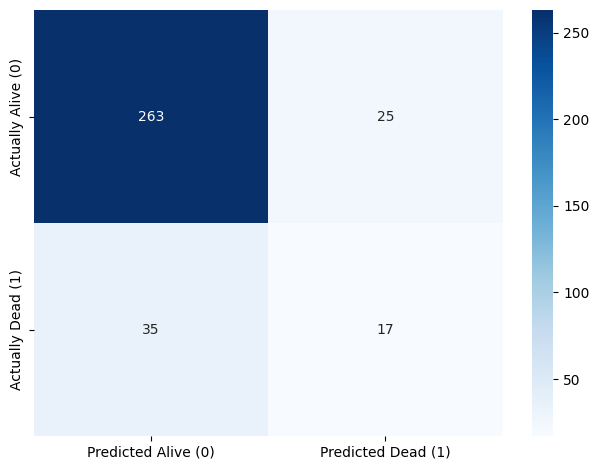

Feature Importances:
       feature  importance
34  D_AD_KBRIG    0.110939
6     IBS_NASL    0.100484
0          AGE    0.091829
7           GB    0.060083
83    TIME_B_S    0.049414
79   AST_BLOOD    0.041977
80   KFK_BLOOD    0.039251
4    FK_STENOK    0.037789
40    SVT_POST    0.036381
1          SEX    0.036009


In [8]:
# predict a lethal outcome using a decision tree (doesn't need feature scaling for labs or BP) 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# create a pipeline that combines the preprocessor with a decision tree classifier
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
# fit the pipeline to the training data
dt_pipeline.fit(X_train, y_train)
# make predictions on the test set
y_pred_dt = dt_pipeline.predict(X_test)

# evaluate the model
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(y_test, y_pred_dt).ravel()
specificity_dt = tn_dt / (tn_dt + fp_dt)
sensitivity_dt = tp_dt / (tp_dt + fn_dt)
print(f"Specificity: {specificity_dt:.3f}")  # ability to correctly identify alive patients
print(f"Sensitivity: {sensitivity_dt:.3f}") # ability to correctly identify dying patients

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

# create a confusion matrix and visualize it with seaborn
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Alive (0)", "Predicted Dead (1)"],
            yticklabels=["Actually Alive (0)", "Actually Dead (1)"])
plt.tight_layout()
plt.show()

# describe which features are most important for predicting lethal outcomes in the decision tree model
feature_importances = dt_pipeline.named_steps["classifier"].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
print("Feature Importances:")
print(feature_importance_df.head(10))   

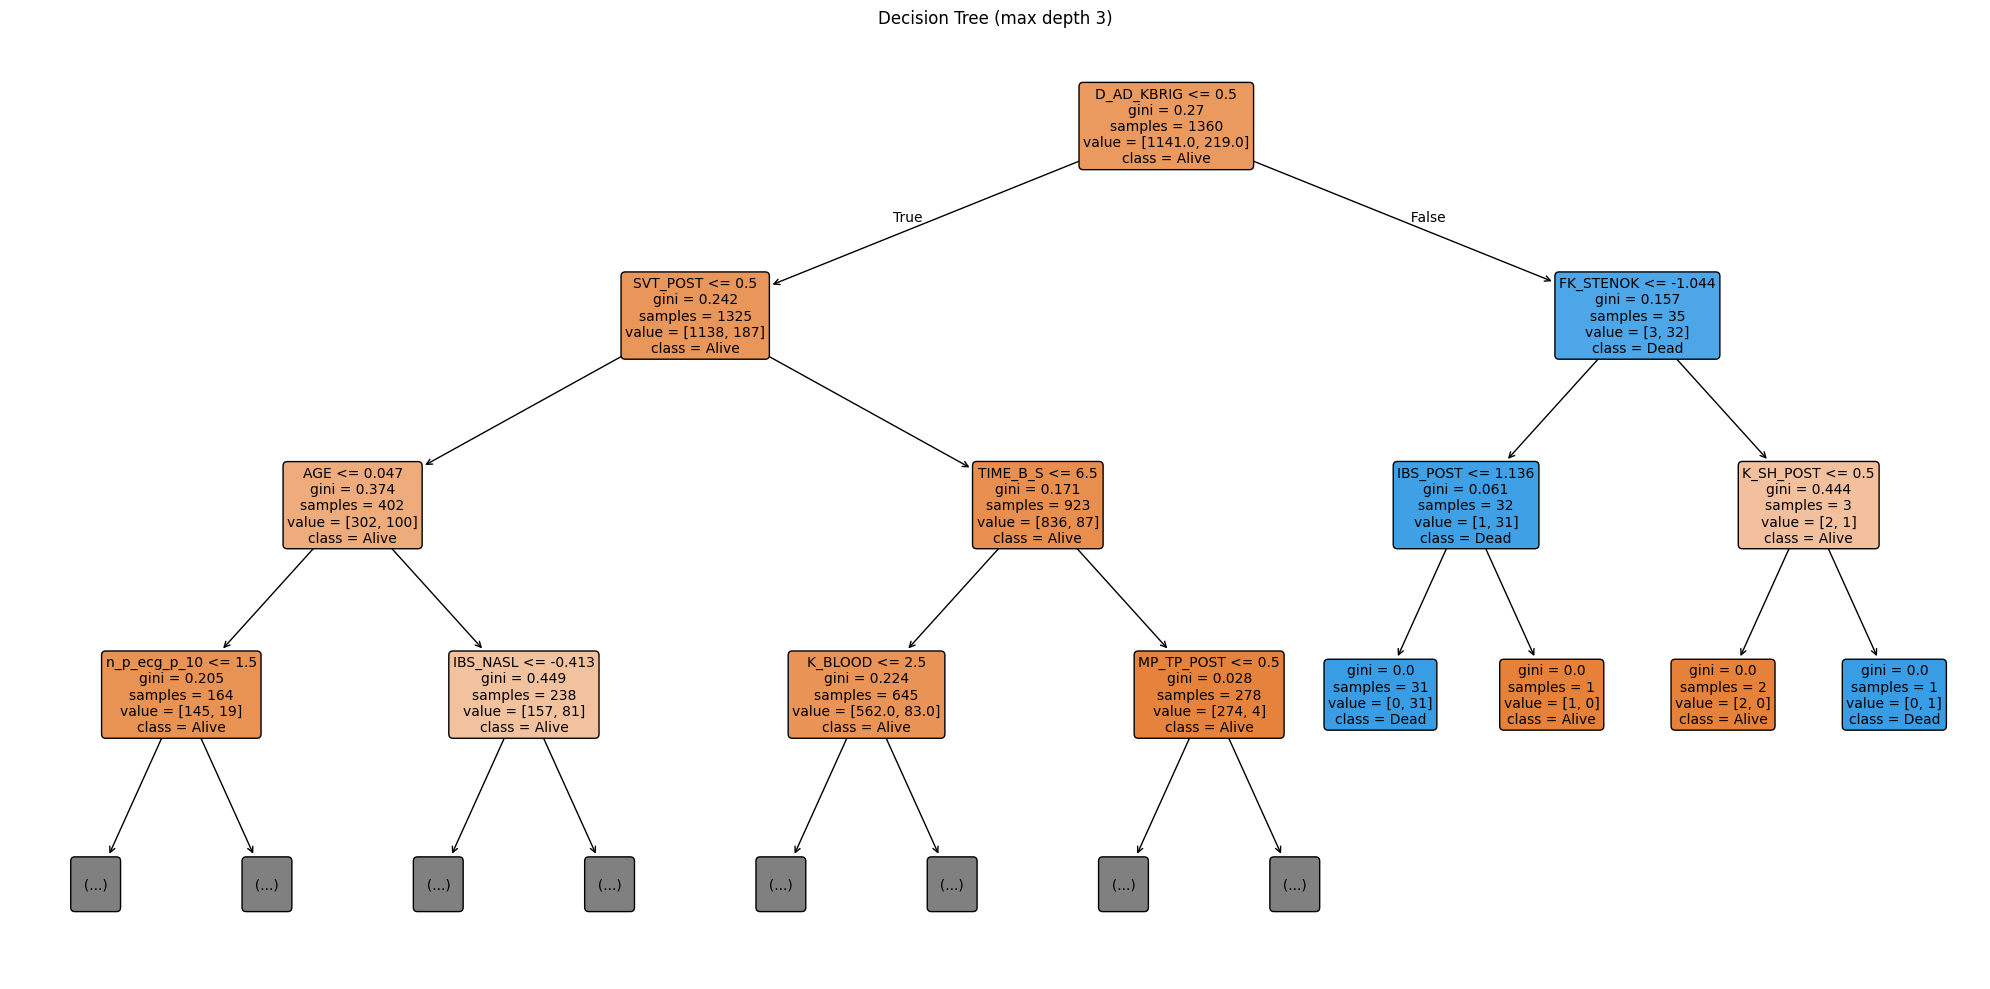

Tree depth: 19
Number of leaves: 155
Number of nodes: 309


In [9]:
# visuzalize the decision tree (limit depth for readability)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_pipeline.named_steps["classifier"],
          max_depth=3,  # limit depth for readability
          feature_names=list(X.columns),
          class_names=["Alive", "Dead"],
          filled=True,  # color nodes by class
          rounded=True,  # rounded boxes
          fontsize=10)
plt.title("Decision Tree (max depth 3)")
plt.tight_layout()
plt.show()

print("Tree depth:", dt_pipeline.named_steps["classifier"].get_depth())
print("Number of leaves:", dt_pipeline.named_steps["classifier"].get_n_leaves())
print("Number of nodes:", dt_pipeline.named_steps["classifier"].tree_.node_count)

### Model 2: Neural Network to predict Lethal Outcome

Neural Network - Specificity:  0.91
Neural Network - Sensitivity:  0.423
Neural Network - Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       288
           1       0.46      0.42      0.44        52

    accuracy                           0.84       340
   macro avg       0.68      0.67      0.67       340
weighted avg       0.83      0.84      0.83       340

Neural Network - Confusion Matrix:


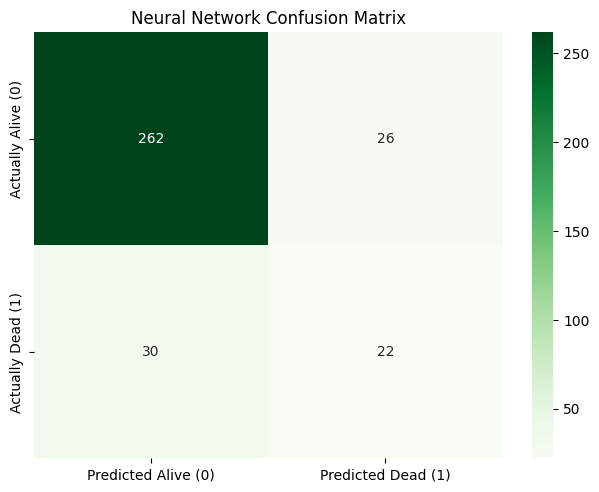

In [10]:
# Neural Network to predict lethal outcome
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pipeline that combines the preprocessor with a neural network classifier
# Using 10 neurons in the hidden layer
nn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(10,),  # 10 neurons in one hidden layer
        max_iter=10000,
        random_state=42,
    ))
])

# Fit the pipeline to the training data
nn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nn = nn_pipeline.predict(X_test)

# Evaluate the model
tn_nn, fp_nn, fn_nn, tp_nn = confusion_matrix(y_test, y_pred_nn).ravel()
specificity_nn = tn_nn / (tn_nn + fp_nn)
sensitivity_nn = tp_nn / (tp_nn + fn_nn)
print("Neural Network - Specificity: ", specificity_nn.round(3))
print("Neural Network - Sensitivity: ", sensitivity_nn.round(3))
print("Neural Network - Classification Report:")
print(classification_report(y_test, y_pred_nn))

# Create a confusion matrix and visualize it
print("Neural Network - Confusion Matrix:")
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Predicted Alive (0)", "Predicted Dead (1)"],
            yticklabels=["Actually Alive (0)", "Actually Dead (1)"])
plt.tight_layout()
plt.title("Neural Network Confusion Matrix")
plt.show()

## 6. Evaluation and Validation

### Comparison of the two models

In [11]:
# Compare with Decision Tree results
print("Comparison of Decision Tree and Neural Network:")
print(f"DT - Sensitivity: {sensitivity_dt:.3f}, Specificity: {specificity_dt:.3f}")
print(f"NN - Sensitivity: {sensitivity_nn:.3f}, Specificity: {specificity_nn:.3f}")

Comparison of Decision Tree and Neural Network:
DT - Sensitivity: 0.327, Specificity: 0.913
NN - Sensitivity: 0.423, Specificity: 0.910


### Discussion: Decision Tree vs Neural Network

In the clinical context for our research question, to predict patient's risk of dying, the Sensitivity of the model is important, i.e. how well the model identifies dying patients. 

The Decision Tree and Neural Network deliver equal Sensitivity, but since the NN has the disatvantage of being a black box, in a clinical context the DT would be the preferred model. 

It can be discussed whether the Sensitivity is sufficient for clinical use, since only a third of dying patients are flagged as high-risk. Possibly more training data is necessary to get better performing models.

### Conclusion
